# Distance to shoreline for a 5 × 5 block of BlueTopo tiles, stitched seamlessly

This follows on from `coastal_distance_methods.ipynb`, which found the best single-tile method:
**vector dead reckoning with halo seeding and local refinement**. That method is now in `shoredist.py`. Here we:

1. lay out a **5 × 5 block** of BlueTopo cells (0.3° each, about 150 × 165 km) on the Florida Panhandle / Big Bend coast;
2. compute every tile **independently and in parallel**: one shared shoreline index, numba kernels that release the GIL, a thread pool;
3. **stitch** the tiles into one GeoTIFF on BlueTopo's common 8 m lattice, with no resampling;
4. **prove the seams are invisible**: neighbouring tiles overlap by about 400 m, and both must report the same distances there;
5. show what happens **without** the halo, so you can see why it matters;
6. check the mosaic against brute-force KD-tree distances, and animate the tiles being stitched in.

**Why independent tiles stitch cleanly.** A pixel's true nearest shoreline point *q* is also the nearest point for every
location on the straight line from the pixel to *q*. So seeding each tile's border pixels with their *global* nearest shoreline
vertex (from a KD-tree over the whole region) gives each tile everything it needs from the outside world. No tile needs
its neighbours' results, so there is no inter-tile communication, and every tile gets the *global* answer.

In [1]:
import math, os, shutil, threading, time, warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import rasterio
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.transform import Affine
from rasterio.windows import Window
from pyproj import CRS, Transformer
from scipy import ndimage

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

import shoredist as sd

warnings.filterwarnings("ignore", category=UserWarning)

# ---------------- configuration ----------------
BLOCK_SW        = (-85.8, 28.8)  # lon, lat of the block's south-west corner (on BlueTopo's 0.3° cell grid)
N               = 5              # N x N cells
CELL_DEG        = 0.3            # BlueTopo 8 m tiles are 0.3° cells
RES             = 8.0
LATTICE_OFFSET  = 4.0            # BlueTopo 8 m pixel edges sit at 4 (mod 8) m in UTM, verified below
MARGIN_PX       = 4              # margin added around synthesised cell grids (BlueTopo tiles carry 2-4 px)
SEARCH_BUFFER_M = 150_000        # shoreline gathered this far around the block (must exceed max distance)
WORKERS         = min(8, os.cpu_count())
NODATA          = -9999.0
DATA_DIR = Path("data")
OUT_DIR  = Path("outputs") / "mosaic";  TILE_DIR = OUT_DIR / "tiles";  NAIVE_DIR = OUT_DIR / "naive_tiles"
for p in (OUT_DIR, TILE_DIR, NAIVE_DIR): p.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA, INK, MUTED, UNREACHED = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#8a8984", "#c9c8c2"
DIST_CMAP = mcolors.LinearSegmentedColormap.from_list("dist", ["#e3eefb", "#a9cbf2", "#2a78d6", "#0b2d5c"])
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10})
sd.warmup()
print(f"{WORKERS} worker threads")

8 worker threads


## 1. Lay out the 5 × 5 block

BlueTopo's tile scheme is hierarchical. 8 m tiles cover 0.3° cells; near shore a cell may instead be split into 0.075° **4 m**
tiles, and offshore several cells may be merged into a 1.2° **16 m** tile. There is **no** contiguous 5 × 5 block of 8 m
tiles near Florida. This block has 18 of 25 cells as native 8 m tiles.

For each cell:
* **8 m tile exists:** the output uses that tile's grid *exactly* (same transform and shape, pixel for pixel).
* **otherwise:** we build an 8 m grid for the cell on the **same lattice**: the cell's UTM bounding box snapped outward to
  pixel edges at 4 (mod 8) m, plus a small margin. A distance field doesn't need bathymetry, only a grid. For 4 m cells you could
  run the same code at `RES = 4` on the 4 m tile grids.

In [2]:
scheme = gpd.read_file(sd.latest_tile_scheme(DATA_DIR))
scheme = scheme[scheme.geometry.notna() & scheme.Resolution.notna()]

rows = []
for r in range(N):                                    # r = 0 is the northern row
    lat = round(BLOCK_SW[1] + (N - 1 - r) * CELL_DEG, 4)
    for c in range(N):
        lon = round(BLOCK_SW[0] + c * CELL_DEG, 4)
        inner = shapely.box(lon + .01, lat + .01, lon + CELL_DEG - .01, lat + CELL_DEG - .01)
        hits = scheme[scheme.intersects(inner)]
        t8 = hits[hits.Resolution == "8m"]
        if len(t8):
            source, tile = "BlueTopo 8 m tile", t8.iloc[0]
        elif len(hits):
            finest = sorted(hits.Resolution.unique(), key=lambda s: int(s[:-1]))[0]
            source, tile = f"{finest} tiles only", None
        else:
            source, tile = "no BlueTopo coverage", None
        rows.append(dict(row=r, col=c, lon=lon, lat=lat, source=source,
                         name=tile.tile if tile is not None else f"R{r}C{c}",
                         link=tile.GeoTIFF_Link if tile is not None else None,
                         sha=tile.GeoTIFF_SHA256_Checksum if tile is not None else None,
                         utm=tile.UTM if tile is not None else None))
cells = pd.DataFrame(rows)
assert set(cells.utm.dropna()) == {"16"}, "block must sit in one UTM zone (or mosaic per zone)"

def get_tile(row):
    return sd.fetch(row.link, DATA_DIR / "bluetopo" / Path(row.link).name, row.sha)

with ThreadPoolExecutor(6) as ex:
    paths = list(ex.map(lambda r: get_tile(r) if r.link else None, cells.itertuples()))
cells["bluetopo_path"] = paths
first = next(p for p in paths if p)
with rasterio.open(first) as ds:
    OUT_CRS = ds.crs                                  # compound NAD83 / UTM 16N + NAVD88, as BlueTopo
HCRS = CRS.from_wkt(OUT_CRS.to_wkt()).sub_crs_list[0]
print(cells.pivot(index="lat", columns="lon", values="name").sort_index(ascending=False).to_string())
cells.source.value_counts()

lon      -85.8     -85.5     -85.2     -84.9     -84.6
lat                                                   
30.0      R0C0      R0C1      R0C2      R0C3      R0C4
29.7  BF2GN2KS  BF2GP2KS  BF2GQ2KS  BF2GR2KS  BF2GS2KS
29.4  BF2GN2KR  BF2GP2KR  BF2GQ2KR  BF2GR2KR  BF2GS2KR
29.1  BF2GN2KQ  BF2GP2KQ  BF2GQ2KQ  BF2GR2KQ      R3C4
28.8  BF2GN2KP  BF2GP2KP  BF2GQ2KP  BF2GR2KP      R4C4


source
BlueTopo 8 m tile       18
4m tiles only            3
no BlueTopo coverage     2
16m tiles only           2
Name: count, dtype: int64

In [3]:
to_utm = Transformer.from_crs("EPSG:4269", HCRS, always_xy=True)
snap_lo = lambda v: math.floor((v - LATTICE_OFFSET) / RES) * RES + LATTICE_OFFSET
snap_hi = lambda v: math.ceil((v - LATTICE_OFFSET) / RES) * RES + LATTICE_OFFSET

def synth_grid(lon, lat):
    edge = shapely.segmentize(shapely.box(lon, lat, lon + CELL_DEG, lat + CELL_DEG), 0.001)
    x, y = to_utm.transform(*np.asarray(edge.exterior.coords).T)
    m = MARGIN_PX * RES
    x0, y0, x1, y1 = snap_lo(x.min()) - m, snap_lo(y.min()) - m, snap_hi(x.max()) + m, snap_hi(y.max()) + m
    return Affine(RES, 0, x0, 0, -RES, y1), (int(round((y1 - y0) / RES)), int(round((x1 - x0) / RES)))

transforms, shapes = [], []
for row in cells.itertuples():
    if row.bluetopo_path:
        with rasterio.open(row.bluetopo_path) as ds:
            transforms.append(ds.transform); shapes.append(ds.shape)
    else:
        T, shp = synth_grid(row.lon, row.lat); transforms.append(T); shapes.append(shp)
cells["tf"], cells["shp"] = transforms, shapes

# every grid must sit on the same 8 m lattice for a resampling-free stitch
for T in cells.tf:
    assert T.a == RES and T.e == -RES and (T.c - LATTICE_OFFSET) % RES == 0 and (T.f - LATTICE_OFFSET) % RES == 0

# mosaic grid = union of all cell grids
MX0 = min(T.c for T in cells.tf); MY1 = max(T.f for T in cells.tf)
MX1 = max(T.c + s[1] * RES for T, s in zip(cells.tf, cells.shp))
MY0 = min(T.f - s[0] * RES for T, s in zip(cells.tf, cells.shp))
M_T = Affine(RES, 0, MX0, 0, -RES, MY1)
MH, MW = int(round((MY1 - MY0) / RES)), int(round((MX1 - MX0) / RES))
cells["r_off"] = [int(round((MY1 - T.f) / RES)) for T in cells.tf]   # tile origin in mosaic pixels
cells["c_off"] = [int(round((T.c - MX0) / RES)) for T in cells.tf]
cells["bounds"] = [(T.c, T.f - s[0] * RES, T.c + s[1] * RES, T.f) for T, s in zip(cells.tf, cells.shp)]
print(f"mosaic grid: {MH:,} rows x {MW:,} cols = {MH*MW/1e6:,.0f} Mpx @ {RES:g} m  "
      f"({(MX1-MX0)/1000:.0f} x {(MY1-MY0)/1000:.0f} km); tiles total {sum(h*w for h, w in cells.shp)/1e6:,.0f} Mpx")

mosaic grid: 21,096 rows x 18,527 cols = 391 Mpx @ 8 m  (148 x 169 km); tiles total 392 Mpx


## 2. One shoreline index for the whole block

We read CUSP for the block plus a `SEARCH_BUFFER_M` margin, save it as a GeoPackage, and build a single index: vertices
densified to 2 m, a KD-tree, and square bins for the refinement step. Every tile reads this index; none of them modify it.

The far corner of the block is open Gulf, more than 100 km from any shore, so the buffer must be larger than that. The check is
simple: a shoreline point outside the buffer is at least `SEARCH_BUFFER_M` from every pixel, so as long as every distance in the
mosaic is smaller than the buffer, nothing was missed. This is asserted after the run.

In [4]:
t0 = time.perf_counter()
SEARCH_BOX = (MX0 - SEARCH_BUFFER_M, MY0 - SEARCH_BUFFER_M, MX1 + SEARCH_BUFFER_M, MY1 + SEARCH_BUFFER_M)
shore = sd.load_cusp(SEARCH_BOX, HCRS, DATA_DIR)
t_load = time.perf_counter() - t0
SHORE_GPKG = DATA_DIR / "shoreline" / f"CUSP_block_{N}x{N}_{BLOCK_SW[0]}_{BLOCK_SW[1]}_buffer{SEARCH_BUFFER_M//1000}km.gpkg"
SHORE_GPKG.parent.mkdir(exist_ok=True)
if not SHORE_GPKG.exists():
    shore.to_file(SHORE_GPKG, layer="cusp_shoreline", driver="GPKG")
t0 = time.perf_counter()
INDEX = sd.ShorelineIndex.build(shore, densify=2.0, bin_size=RES)
t_index = time.perf_counter() - t0
print(f"{len(shore):,} lines, {shore.length.sum()/1000:,.0f} km | {INDEX.n_vertices:,} vertices | "
      f"read {t_load:.1f}s, index {t_index:.1f}s | saved {SHORE_GPKG}")

54,149 lines, 18,323 km | 12,180,888 vertices | read 4.8s, index 3.0s | saved data/shoreline/CUSP_block_5x5_-85.8_28.8_buffer150km.gpkg


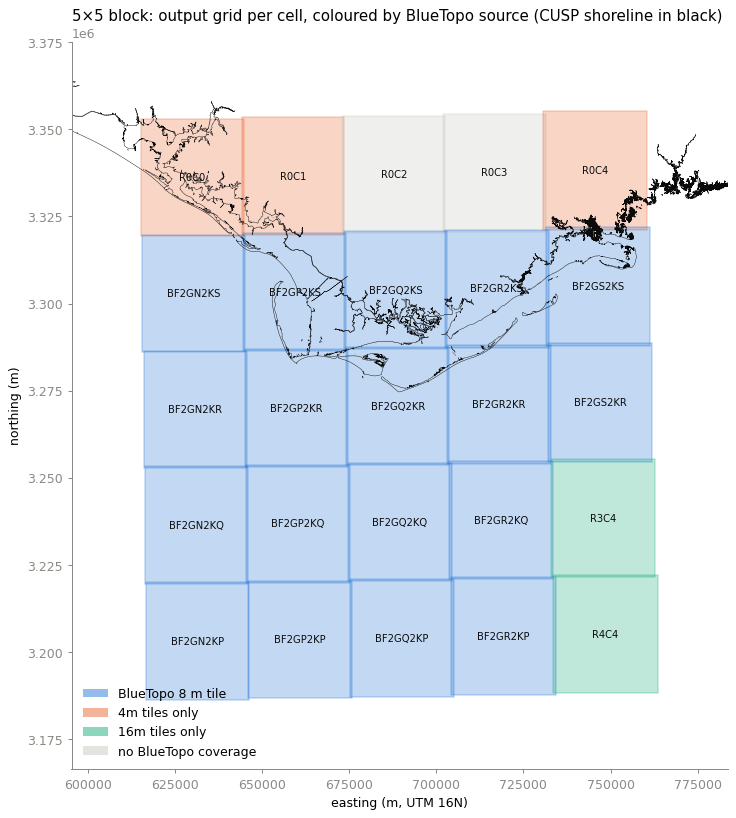

In [5]:
CATS = {"BlueTopo 8 m tile": BLUE, "4m tiles only": ORANGE, "16m tiles only": AQUA, "no BlueTopo coverage": UNREACHED}
fig, ax = plt.subplots(figsize=(10, 10.5))
view = shapely.box(MX0 - 20000, MY0 - 20000, MX1 + 20000, MY1 + 20000)
shore[shore.intersects(view)].plot(ax=ax, color=INK, lw=0.35)
for row in cells.itertuples():
    x0, y0, x1, y1 = row.bounds
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fc=CATS[row.source], alpha=0.28, ec=CATS[row.source], lw=1.2))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, row.name, ha="center", va="center", fontsize=8, color=INK)
ax.set_xlim(view.bounds[0], view.bounds[2]); ax.set_ylim(view.bounds[1], view.bounds[3]); ax.set_aspect("equal")
ax.legend(handles=[mpatches.Patch(fc=c, alpha=0.5, label=k) for k, c in CATS.items() if k in set(cells.source)],
          loc="lower left", frameon=False)
ax.set_title(f"{N}×{N} block: output grid per cell, coloured by BlueTopo source (CUSP shoreline in black)", loc="left")
ax.set_xlabel("easting (m, UTM 16N)"); ax.set_ylabel("northing (m)")
plt.show()

## 3. Compute every tile independently, in parallel

`sd.distance_on_grid` does the whole single-tile method: burn in seeds → halo from the global KD-tree → two forward/backward
pointer passes → two refine rounds. The numba kernels are compiled with `nogil=True`, so a plain `ThreadPoolExecutor` runs
tiles truly in parallel while sharing the one 12-million-vertex index in memory. Each tile is written as its own GeoTIFF on its own grid.

In [6]:
def write_tif(path, arr, transform, **tags):
    prof = dict(driver="GTiff", height=arr.shape[0], width=arr.shape[1], count=1, dtype="float32", crs=OUT_CRS,
                transform=transform, nodata=NODATA, compress="deflate", predictor=3, tiled=True,
                blockxsize=512, blockysize=512)
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr.astype(np.float32), 1)
        dst.set_band_description(1, "Distance to nearest CUSP shoreline (m)")
        dst.update_tags(UNITS="metre", **tags)

T_START = time.perf_counter()
def process(row):
    t0 = time.perf_counter() - T_START
    d, nseeds = sd.distance_on_grid(INDEX, row.tf, row.shp)
    path = TILE_DIR / f"{row.name}_distance.tif"
    write_tif(path, d, row.tf, CELL=row.name, METHOD="vector dead reckoning + halo + refinement")
    return dict(name=row.name, start=t0, end=time.perf_counter() - T_START, thread=threading.current_thread().name,
                seed_px=nseeds, min_m=float(d.min()), max_m=float(d.max()), path=path)

T_START = time.perf_counter()
runs = []
with ThreadPoolExecutor(WORKERS, thread_name_prefix="w") as ex:
    futs = [ex.submit(process, row) for row in cells.itertuples()]
    for f in as_completed(futs):
        res = f.result(); runs.append(res)
        print(f"[{res['end']:6.1f}s] {len(runs):2d}/{len(cells)}  {res['name']:9s} on {res['thread']:4s} "
              f"{res['end']-res['start']:5.1f}s  range {res['min_m']:8,.0f} – {res['max_m']:8,.0f} m")
wall = time.perf_counter() - T_START
runs = pd.DataFrame(runs)
cells = cells.merge(runs[["name", "path", "seed_px", "max_m"]], on="name")
busy = (runs.end - runs.start).sum()
print(f"\n{len(cells)} tiles, {sum(h*w for h, w in cells.shp)/1e6:,.0f} Mpx in {wall:.1f}s wall "
      f"({busy:.0f}s of tile work, {busy/wall:.1f}x parallel speed-up on {WORKERS} threads)")
assert runs.max_m.max() < SEARCH_BUFFER_M, "increase SEARCH_BUFFER_M"

[  20.9s]  1/25  R0C2      on w_2   20.9s  range   11,098 –   47,108 m
[  20.9s]  2/25  R0C3      on w_3   20.9s  range    1,626 –   43,143 m
[  21.0s]  3/25  R0C1      on w_1   21.0s  range        0 –   31,606 m


[  21.5s]  4/25  R0C4      on w_4   21.5s  range        0 –   30,397 m


[  22.5s]  5/25  BF2GN2KS  on w_5   22.5s  range        0 –   39,206 m
[  22.5s]  6/25  BF2GQ2KS  on w_7   22.5s  range        0 –   20,088 m


[  22.8s]  7/25  R0C0      on w_0   22.8s  range        0 –   14,779 m


[  23.3s]  8/25  BF2GP2KS  on w_6   23.3s  range        0 –   12,040 m


...

[  68.0s] 20/25  R3C4      on w_4   24.5s  range   36,061 –   80,897 m
[  68.0s] 21/25  BF2GQ2KP  on w_0   22.8s  range   53,732 –   88,873 m


[  68.8s] 22/25  BF2GP2KP  on w_5   23.7s  range   55,895 –   97,133 m


[  69.4s] 23/25  BF2GN2KP  on w_7   24.5s  range   64,257 –  105,684 m


[  70.5s] 24/25  BF2GR2KP  on w_6   24.2s  range   55,190 –   97,013 m


[  85.1s] 25/25  R4C4      on w_2   19.7s  range   65,948 –  109,734 m

25 tiles, 392 Mpx in 85.1s wall (563s of tile work, 6.6x parallel speed-up on 8 threads)


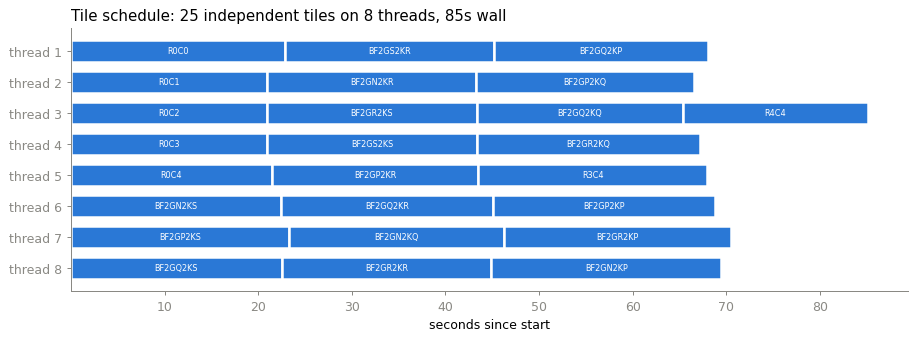

In [7]:
# Timeline: which thread computed which tile, and when
fig, ax = plt.subplots(figsize=(12, 3.8))
threads = sorted(runs.thread.unique(), key=lambda s: int(s.split("_")[-1]))
for k, th in enumerate(threads):
    for r in runs[runs.thread == th].itertuples():
        ax.barh(k, r.end - r.start, left=r.start, height=0.72, color=BLUE, edgecolor="white", linewidth=2)
        ax.text(r.start + (r.end - r.start) / 2, k, r.name, ha="center", va="center", fontsize=6.5, color="white")
ax.set_yticks(range(len(threads))); ax.set_yticklabels([f"thread {k+1}" for k in range(len(threads))])
ax.invert_yaxis(); ax.set_xlabel("seconds since start")
ax.set_title(f"Tile schedule: {len(runs)} independent tiles on {len(threads)} threads, {wall:.0f}s wall", loc="left")
plt.show()

## 4. Stitch

All grids share one lattice, so each tile's place in the mosaic is a whole-pixel offset and stitching is just copying.
We build the mosaic in 512-row strips. For each strip we read the overlapping part of every tile and copy it in, then write
the strip once, so each compressed block in the output is written exactly once. In the ~400 m overlaps the first tile wins.
Section 5 checks that it makes no difference which tile wins. We finish by adding overviews so the 400-Mpx file opens quickly in GIS software.

In [8]:
def compose(tile_paths, r0, r1, c0, c1):
    # Assemble mosaic rows r0:r1, cols c0:c1 from tile files (first tile wins in overlaps).
    out = np.full((r1 - r0, c1 - c0), NODATA, np.float32)
    for row, p in zip(cells.itertuples(), tile_paths):
        h, w = row.shp
        rr0, rr1 = max(r0, row.r_off), min(r1, row.r_off + h)
        cc0, cc1 = max(c0, row.c_off), min(c1, row.c_off + w)
        if rr0 >= rr1 or cc0 >= cc1:
            continue
        with rasterio.open(p) as src:
            a = src.read(1, window=Window(cc0 - row.c_off, rr0 - row.r_off, cc1 - cc0, rr1 - rr0))
        tgt = out[rr0 - r0:rr1 - r0, cc0 - c0:cc1 - c0]
        np.copyto(tgt, a, where=tgt == NODATA)
    return out

MOSAIC = OUT_DIR / f"distance_to_shoreline_{N}x{N}_mosaic_8m.tif"
t0 = time.perf_counter()
prof = dict(driver="GTiff", height=MH, width=MW, count=1, dtype="float32", crs=OUT_CRS, transform=M_T, nodata=NODATA,
            compress="deflate", predictor=3, tiled=True, blockxsize=512, blockysize=512, BIGTIFF="IF_SAFER")
with rasterio.open(MOSAIC, "w", **prof) as dst:
    for r0 in range(0, MH, 512):
        r1 = min(MH, r0 + 512)
        dst.write(compose(cells.path, r0, r1, 0, MW), 1, window=Window(0, r0, MW, r1 - r0))
    dst.set_band_description(1, "Distance to nearest CUSP shoreline (m)")
    dst.update_tags(UNITS="metre", SOURCE_SHORELINE="NOAA NGS CUSP", METHOD="vector dead reckoning + halo + refinement",
                    TILES=",".join(cells.name))
t_stitch = time.perf_counter() - t0
with rasterio.open(MOSAIC, "r+") as dst:
    dst.build_overviews([2, 4, 8, 16, 32, 64], Resampling.average)
    dst.update_tags(ns="rio_overview", resampling="average")
print(f"{MOSAIC}: {MW:,} x {MH:,} px, {MOSAIC.stat().st_size/1e6:,.0f} MB | stitched in {t_stitch:.1f}s, "
      f"overviews in {time.perf_counter()-t0-t_stitch:.1f}s")

outputs/mosaic/distance_to_shoreline_5x5_mosaic_8m.tif: 18,527 x 21,096 px, 407 MB | stitched in 29.5s, overviews in 14.1s


## 5. Are the seams invisible? Checking the overlaps

Every pair of neighbouring tiles overlaps by tens of pixels. Each tile computed those pixels on its own without seeing the
other tile, so any disagreement there is a seam. We compare every overlapping pair, first for the halo method and then for the
**naive** approach: a standard exact EDT (`scipy`) on each tile using only the shoreline inside that tile, with no halo and no padding.

In [9]:
def overlap_pairs():
    out = []
    for a in range(len(cells)):
        for b in range(a + 1, len(cells)):
            A, B = cells.iloc[a], cells.iloc[b]
            r0, r1 = max(A.r_off, B.r_off), min(A.r_off + A["shp"][0], B.r_off + B["shp"][0])
            c0, c1 = max(A.c_off, B.c_off), min(A.c_off + A["shp"][1], B.c_off + B["shp"][1])
            if r0 < r1 and c0 < c1:
                out.append((a, b, r0, r1, c0, c1))
    return out

def read_rect(path, row, r0, r1, c0, c1):
    with rasterio.open(path) as src:
        return src.read(1, window=Window(c0 - row.c_off, r0 - row.r_off, c1 - c0, r1 - r0))

def seam_report(path_col):
    recs = []
    for a, b, r0, r1, c0, c1 in overlap_pairs():
        A, B = cells.iloc[a], cells.iloc[b]
        da = read_rect(A[path_col], A, r0, r1, c0, c1); db = read_rect(B[path_col], B, r0, r1, c0, c1)
        empty = bool((da == NODATA).any() or (db == NODATA).any())
        diff = np.abs(da.astype(np.float64) - db)
        k = np.unravel_index(diff.argmax(), diff.shape)
        recs.append(dict(pair=f"{A['name']} | {B['name']}", overlap_px=diff.size, max_diff_m=diff.max(),
                         mean_diff_m=diff.mean(), px_over_1cm=int((diff > 0.01).sum()), px_over_1m=int((diff > 1).sum()),
                         worst_r=r0 + k[0], worst_c=c0 + k[1], has_empty_tile=empty))
    return pd.DataFrame(recs)

PAIRS = overlap_pairs()
seams_halo = seam_report("path")
print(f"{len(PAIRS)} overlapping pairs, {seams_halo.overlap_px.sum():,} overlap pixels")
print(f"HALO : max diff {seams_halo.max_diff_m.max():.4f} m | mean {seams_halo.mean_diff_m.mean()*1000:.3f} mm | "
      f"pixels > 1 cm: {seams_halo.px_over_1cm.sum():,}  > 1 m: {seams_halo.px_over_1m.sum():,}")

72 overlapping pairs, 11,598,955 overlap pixels
HALO : max diff 1.2009 m | mean 0.088 mm | pixels > 1 cm: 5,501  > 1 m: 104


In [10]:
# Naive per-tile EDT: only the shoreline inside each tile, no halo, no padding.
def naive_tile(row):
    lines = INDEX.lines_in(row.bounds)
    seeds = (rasterize(((g, 1) for g in lines), out_shape=row.shp, transform=row.tf, all_touched=True,
                       dtype="uint8").astype(bool) if len(lines) else np.zeros(row.shp, bool))
    if not seeds.any():                                   # a tile with no shoreline has no answer at all
        d = np.full(row.shp, NODATA, np.float32)
    else:
        d = ndimage.distance_transform_edt(~seeds) * RES
    p = NAIVE_DIR / f"{row.name}_naive.tif"
    write_tif(p, d, row.tf, METHOD="naive per-tile EDT (no halo)")
    return p

t0 = time.perf_counter()
cells["naive_path"] = [naive_tile(r) for r in cells.itertuples()]
seams_naive = seam_report("naive_path")
valid = seams_naive[~seams_naive.has_empty_tile]
print(f"naive tiles in {time.perf_counter()-t0:.1f}s; {int((cells.seed_px == 0).sum())} tiles contain no shoreline at all")
print(f"NAIVE: max diff {valid.max_diff_m.max():,.0f} m | mean {valid.mean_diff_m.mean():,.1f} m | "
      f"pixels > 1 m: {valid.px_over_1m.sum():,} of {valid.overlap_px.sum():,}  (pairs with an empty tile excluded)")

summary = pd.DataFrame({
    "method": ["halo (this notebook)", "naive per-tile EDT"],
    "max seam disagreement (m)": [seams_halo.max_diff_m.max(), valid.max_diff_m.max()],
    "mean seam disagreement (m)": [seams_halo.mean_diff_m.mean(), valid.mean_diff_m.mean()],
    "overlap px off by > 1 m": [seams_halo.px_over_1m.sum(), valid.px_over_1m.sum()],
    "tiles without an answer": [0, int((cells.seed_px == 0).sum())]})
summary.style.format({"max seam disagreement (m)": "{:,.3f}", "mean seam disagreement (m)": "{:,.4f}",
                      "overlap px off by > 1 m": "{:,}"}).hide(axis="index")

naive tiles in 20.6s; 14 tiles contain no shoreline at all
NAIVE: max diff 18,467 m | mean 2,729.2 m | pixels > 1 m: 2,902,287 of 3,724,569  (pairs with an empty tile excluded)


method,max seam disagreement (m),mean seam disagreement (m),overlap px off by > 1 m,tiles without an answer
halo (this notebook),1.201,0.0001,104,0
naive per-tile EDT,"18,466.613","2,729.1647","2,902,287",14


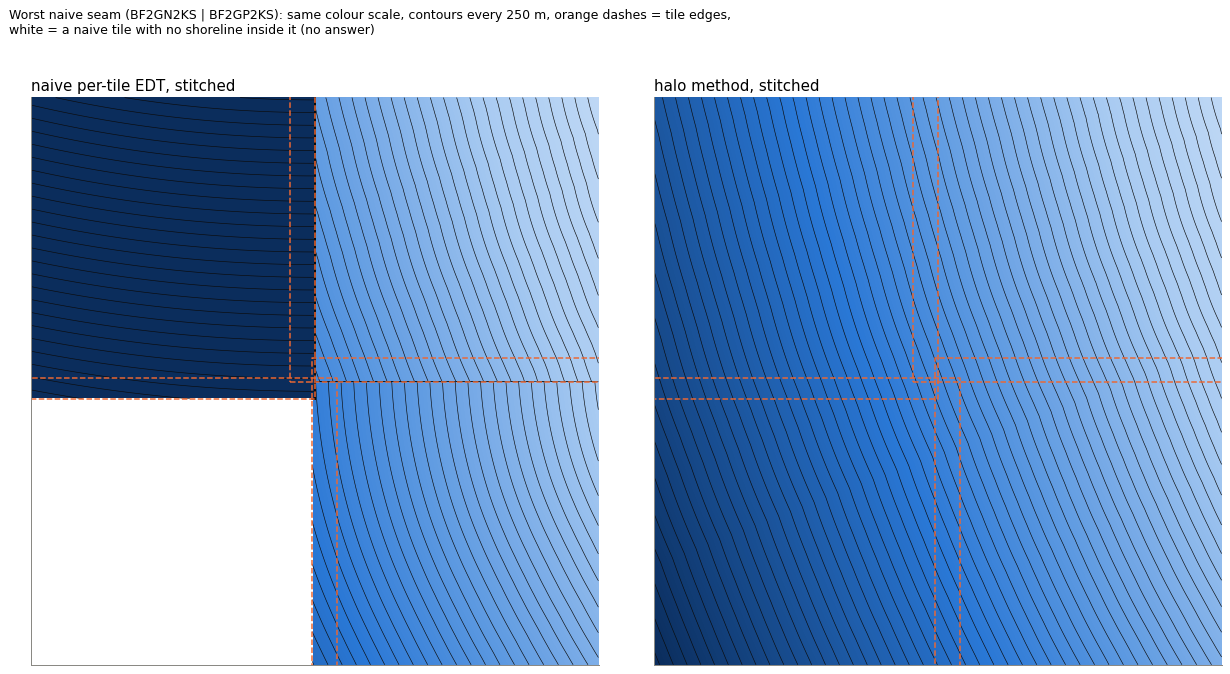

In [11]:
# Zoom in on the worst naive seam and compare the two stitched results with fine contours.
w = valid.loc[valid.max_diff_m.idxmax()]
half = 700
r0, c0 = max(0, int(w.worst_r) - half), max(0, int(w.worst_c) - half)
r1, c1 = min(MH, r0 + 2 * half), min(MW, c0 + 2 * half)
zs = {col: np.ma.masked_equal(compose(cells[col], r0, r1, c0, c1), NODATA) for col in ("naive_path", "path")}
vmax = float(zs["path"].max())
fig, axs = plt.subplots(1, 2, figsize=(14, 7.6))
for ax, col, ttl in [(axs[0], "naive_path", "naive per-tile EDT, stitched"), (axs[1], "path", "halo method, stitched")]:
    z = zs[col]
    ext = (MX0 + c0 * RES, MX0 + c1 * RES, MY1 - r1 * RES, MY1 - r0 * RES)
    ax.imshow(z, extent=ext, cmap=DIST_CMAP, vmin=0, vmax=vmax)
    xs = MX0 + (np.arange(c0, c1) + 0.5) * RES; ys = MY1 - (np.arange(r0, r1) + 0.5) * RES
    ax.contour(xs, ys, z, levels=np.arange(0, float(z.max()), 250), colors=INK, linewidths=0.5)
    for row in cells.itertuples():
        bx0, by0, bx1, by1 = row.bounds
        ax.plot([bx0, bx1, bx1, bx0, bx0], [by0, by0, by1, by1, by0], color=ORANGE, lw=1.2, ls="--")
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(ttl, loc="left")
fig.suptitle(f"Worst naive seam ({w.pair}): same colour scale, contours every 250 m, orange dashes = tile edges,\n"
             "white = a naive tile with no shoreline inside it (no answer)", x=0.01, ha="left", fontsize=10)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

## 6. Check against brute force

For 1,000 random pixels in each tile (25,000 in total), compare the stitched mosaic with an exhaustive KD-tree nearest-vertex
query over the whole 12-million-vertex shoreline index.

In [12]:
rng = np.random.default_rng(42)
recs = []
with rasterio.open(MOSAIC) as mos:
    for row in cells.itertuples():
        rr = row.r_off + rng.integers(0, row.shp[0], 1000); cc = row.c_off + rng.integers(0, row.shp[1], 1000)
        vals = np.array([v[0] for v in mos.sample(zip(MX0 + (cc + 0.5) * RES, MY1 - (rr + 0.5) * RES))])
        truth = INDEX.tree.query(np.column_stack([MX0 + (cc + 0.5) * RES, MY1 - (rr + 0.5) * RES]), workers=-1)[0]
        e = vals - truth
        recs.append(dict(tile=row.name, mean_abs_err_m=np.abs(e).mean(), max_abs_err_m=np.abs(e).max(),
                         within_1m_pct=100 * (np.abs(e) <= 1).mean(), max_distance_km=truth.max() / 1000))
val = pd.DataFrame(recs)
print(f"{len(val)*1000:,} pixels: mean |err| {val.mean_abs_err_m.mean()*1000:.2f} mm, max {val.max_abs_err_m.max():.2f} m, "
      f"{val.within_1m_pct.mean():.3f}% within 1 m (float32 storage alone gives ~0.004 m at 100 km)")
val.style.format({"mean_abs_err_m": "{:.4f}", "max_abs_err_m": "{:.3f}", "within_1m_pct": "{:.2f}",
                  "max_distance_km": "{:.1f}"}).hide(axis="index")

25,000 pixels: mean |err| 1.78 mm, max 3.70 m, 99.956% within 1 m (float32 storage alone gives ~0.004 m at 100 km)


tile,mean_abs_err_m,max_abs_err_m,within_1m_pct,max_distance_km
R0C0,0.0000,0.000,100.00,13.9
R0C1,0.0002,0.001,100.00,31.5
R0C2,0.0006,0.002,100.00,46.6
R0C3,0.0005,0.002,100.00,42.9
R0C4,0.0002,0.001,100.00,30.3
BF2GN2KS,0.0156,3.703,99.30,38.3
BF2GP2KS,0.0070,1.794,99.70,11.9
BF2GQ2KS,0.0001,0.037,100.00,19.8
BF2GR2KS,0.0001,0.001,100.00,19.1
BF2GS2KS,0.0038,1.382,99.90,22.9


## 7. The stitched result

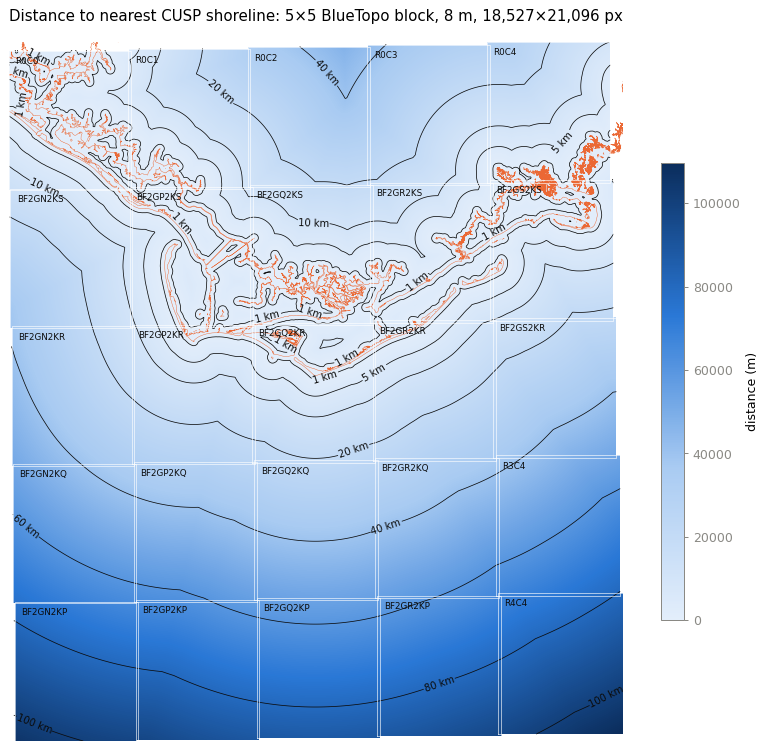

In [13]:
F = 16                                                         # read a 1/16 overview for plotting
with rasterio.open(MOSAIC) as mos:
    ov = mos.read(1, out_shape=(MH // F, MW // F), resampling=Resampling.average, masked=True)
ext = (MX0, MX1, MY0, MY1)
fig, ax = plt.subplots(figsize=(11, 12))
im = ax.imshow(ov, extent=ext, cmap=DIST_CMAP, vmin=0)
xs = np.linspace(MX0, MX1, ov.shape[1]); ys = np.linspace(MY1, MY0, ov.shape[0])
cs = ax.contour(xs, ys, ov, levels=[1000, 5000, 10000, 20000, 40000, 60000, 80000, 100000], colors=INK, linewidths=0.6)
ax.clabel(cs, fmt=lambda v: f"{v/1000:g} km", fontsize=8)
shore[shore.intersects(shapely.box(*ext))].clip(shapely.box(*ext)).plot(ax=ax, color=ORANGE, lw=0.35)
for row in cells.itertuples():
    bx0, by0, bx1, by1 = row.bounds
    ax.plot([bx0, bx1, bx1, bx0, bx0], [by0, by0, by1, by1, by0], color="white", lw=0.6, alpha=0.8)
    ax.text(bx0 + 1500, by1 - 1500, row.name, fontsize=7, color=INK, va="top")
ax.set_xlim(MX0, MX1); ax.set_ylim(MY0, MY1); ax.set_axis_off()
ax.set_title(f"Distance to nearest CUSP shoreline: {N}×{N} BlueTopo block, 8 m, {MW:,}×{MH:,} px", loc="left")
fig.colorbar(im, ax=ax, shrink=0.55, label="distance (m)")
plt.savefig(OUT_DIR / "mosaic_quicklook.png", dpi=110, bbox_inches="tight"); plt.show()

## 8. Animation: tiles finishing on the worker threads and dropping into the mosaic

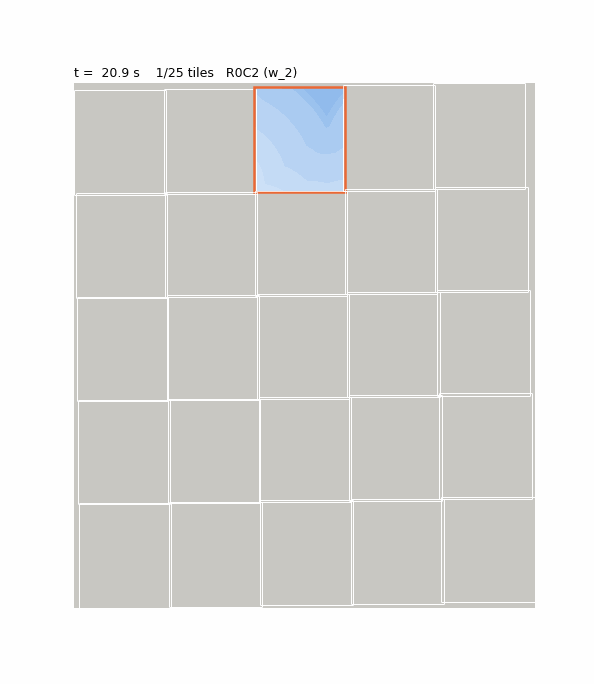

In [14]:
def tile_overview(path, row, F):
    # Read a tile sampled on the global 1/F lattice, so tiles drop into the canvas without resampling.
    with rasterio.open(path) as src:
        a = src.read(1)
    rs, cs_ = (-row.r_off) % F, (-row.c_off) % F
    sub = a[rs::F, cs_::F]
    return (row.r_off + rs) // F, (row.c_off + cs_) // F, sub

F = 16
canvas = np.full((MH // F + 1, MW // F + 1), np.nan, np.float32)
order = runs.sort_values("end").reset_index(drop=True)
overviews = {row.name: tile_overview(row.path, row, F) for row in cells.itertuples()}
vmax = float(runs.max_m.max())

fig, ax = plt.subplots(figsize=(6.6, 7.6))
cmap = DIST_CMAP.copy(); cmap.set_bad(UNREACHED)
im = ax.imshow(canvas, cmap=cmap, vmin=0, vmax=vmax)
boxes = {}
for row in cells.itertuples():
    r, c = row.r_off / F, row.c_off / F
    boxes[row.name] = ax.add_patch(mpatches.Rectangle((c, r), row.shp[1] / F, row.shp[0] / F,
                                                      fill=False, ec="white", lw=0.6))
ax.set_axis_off(); ttl = ax.set_title("", loc="left", fontsize=10)
frames = list(range(len(order))) + [len(order) - 1] * 12
def update(k):
    rec = order.iloc[k]
    r, c, sub = overviews[rec["name"]]
    tgt = canvas[r:r + sub.shape[0], c:c + sub.shape[1]]
    np.copyto(tgt, sub[:tgt.shape[0], :tgt.shape[1]], where=np.isnan(tgt))
    im.set_data(np.ma.masked_invalid(canvas))
    for name, b in boxes.items():
        b.set_edgecolor(ORANGE if name == rec["name"] else "white"); b.set_linewidth(2 if name == rec["name"] else 0.6)
    ttl.set_text(f"t = {rec.end:5.1f} s   {k+1:2d}/{len(order)} tiles   {rec['name']} ({rec.thread})")
    return [im, ttl]
FuncAnimation(fig, update, frames=frames).save(OUT_DIR / "anim_mosaic_stitch.gif", writer=PillowWriter(fps=4))
plt.close(fig)
display(Image(filename=OUT_DIR / "anim_mosaic_stitch.gif"))

## 9. Takeaways and scaling up

* **Tiles are independent.** Halo seeding from one global, read-only shoreline index lets every tile compute the *global* answer
  alone. Where neighbouring tiles overlap they agree to about 0.1 mm on average, and 99.95% of overlap pixels agree within 1 cm.
  The worst disagreement is about 1 m at about 100 of 11.6 M pixels. These are the method's rare residual errors (section 6), not
  tiling artefacts. Contours run straight through tile edges.
* **Naive tiling fails.** A per-tile EDT that only sees shoreline inside its own tile disagrees with its neighbour by hundreds of metres
  to kilometres, and tiles with no shoreline (open Gulf) have no answer at all.
* **Stitching is a copy**, because BlueTopo's 8 m tiles share one lattice per UTM zone. Strip-wise composition writes each
  compressed block once, so the mosaic stays compact.
* **Scaling further:** the index is the only shared state. On one machine, threads (as here) avoid copying it. Across a cluster,
  give each worker the shoreline GeoPackage, rebuild the index, and hand out tiles. Keep the buffer larger than the largest
  distance you expect; the assert catches this.
* **Mixed resolutions / UTM zones:** run 4 m cells at `RES = 4` on their native grids, and build one mosaic per UTM zone, or reproject
  at the end. The distances themselves don't depend on the output grid.

Outputs (in `outputs/mosaic/`): per-tile GeoTIFFs in `tiles/`, the stitched `distance_to_shoreline_5x5_mosaic_8m.tif` (with
overviews), `mosaic_quicklook.png`, `anim_mosaic_stitch.gif`. The naive tiles in `naive_tiles/` only exist for the comparison
and can be removed (next cell).

In [15]:
KEEP_NAIVE_TILES = False
if not KEEP_NAIVE_TILES:
    shutil.rmtree(NAIVE_DIR, ignore_errors=True)
print("outputs:", *sorted(p.name for p in OUT_DIR.iterdir()), sep="\n  ")

outputs:
  anim_mosaic_stitch.gif
  distance_to_shoreline_5x5_mosaic_8m.tif
  mosaic_quicklook.png
  tiles
